In [1]:
import control as ct

In [2]:
s =ct.tf('s')

In [22]:
L=(5.5+4.7)*1E-3
R=2*0.01
Tf=L/R
Fs=10E3
Ts=1/Fs
print('L=',L,'R=',R)
print('Ts=',Ts)

L= 0.010199999999999999 R= 0.02
Ts= 0.0001


In [23]:
G1=1/(L*s+R)
print(G)

<TransferFunction>: sys[36]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ---------------
  0.0102 s + 0.02


In [24]:
D=1/(1+1.5*Ts*s)
print(D)

<TransferFunction>: sys[42]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        1
  -------------
  0.00015 s + 1


In [31]:
plant=G1*D
print(plant)

<TransferFunction>: sys[50]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                1
  ------------------------------
  1.53e-06 s^2 + 0.0102 s + 0.02


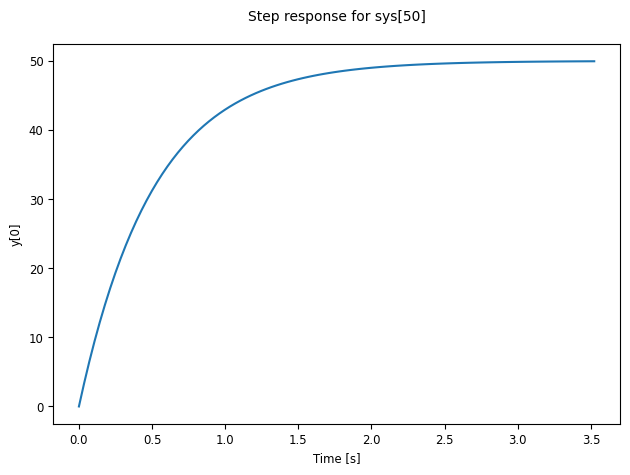

In [33]:
response = ct.step_response(plant)
cplt = response.plot()

In [27]:
Kp=L/(3*Ts)
print('Kp=',Kp)

Kp= 33.99999999999999


In [28]:
Ki=Kp/Tf
print('Ki=',Ki)

Ki= 66.66666666666667


In [30]:
PI=Kp+Ki/s
print(PI)

<TransferFunction>: sys[49]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  34 s + 66.67
  ------------
       s


In [37]:
Gopen=PI*plant
print(Gopen)

<TransferFunction>: sys[67]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             34 s + 66.67
  ----------------------------------
  1.53e-06 s^3 + 0.0102 s^2 + 0.02 s


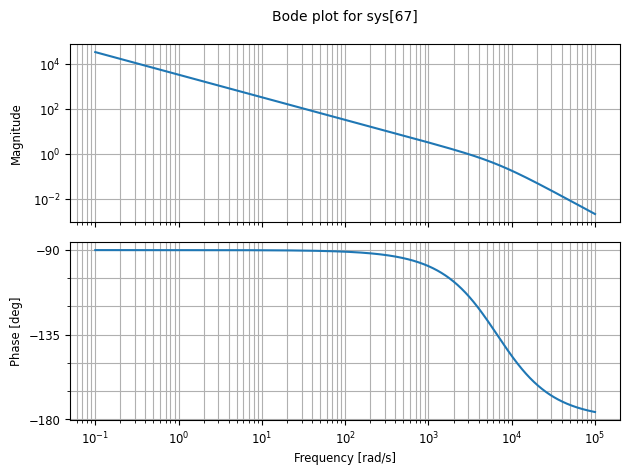

In [42]:
freqresp = ct.frequency_response(Gopen)
cplt = freqresp.plot()

In [38]:
G=Gopen/(1+Gopen)
print(G)

<TransferFunction>: sys[70]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                   5.202e-05 s^4 + 0.347 s^3 + 1.36 s^2 + 1.333 s
  --------------------------------------------------------------------------------
  2.341e-12 s^6 + 3.122e-08 s^5 + 0.0001562 s^4 + 0.3474 s^3 + 1.361 s^2 + 1.333 s


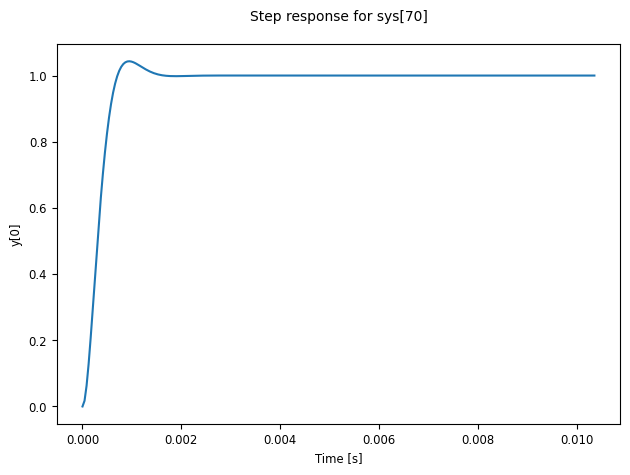

In [39]:
response = ct.step_response(G)
cplt = response.plot()

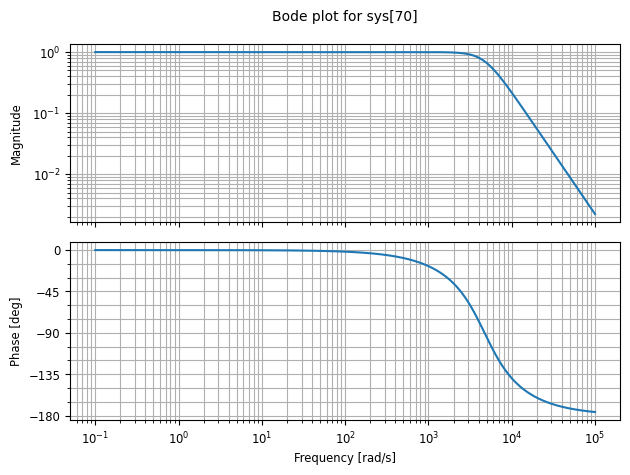

In [41]:
freqresp = ct.frequency_response(G)
cplt = freqresp.plot()